
# Задание 1. Карточка рецепта

Получите рецепт:

```text
/recipes/1
```

Выведите:

- название;
- кухню;
- сложность;
- время подготовки;
- время приготовления;
- рейтинг.

### Пример результата

```text
Название: Classic Margherita Pizza
Кухня: Italian
Сложность: Easy
Подготовка: 20 мин.
Приготовление: 15 мин.
Рейтинг: 4.6
```

Эти данные соответствуют текущему рецепту с ID `1`. https://dummyjson.com/recipes/1

---

In [1]:

import requests

"""
{'id': 1, 'name': 'Classic Margherita Pizza', 'ingredients': ['Pizza dough', 'Tomato sauce', 'Fresh mozzarella cheese', 'Fresh basil leaves', 'Olive oil', 'Salt and pepper to taste'], 'instructions': ['Preheat the oven to 475°F (245°C).', 'Roll out the pizza dough and spread tomato sauce evenly.', 'Top with slices of fresh mozzarella and fresh basil leaves.', 'Drizzle with olive oil and season with salt and pepper.', 'Bake in the preheated oven for 12-15 minutes or until the crust is golden brown.', 'Slice and serve hot.'], 'prepTimeMinutes': 20, 'cookTimeMinutes': 15, 'servings': 4, 'difficulty': 'Easy', 'cuisine': 'Italian', 'caloriesPerServing': 300, 'tags': ['Pizza', 'Italian'], 'userId': 166, 'image': 'https://cdn.dummyjson.com/recipe-images/1.webp', 'rating': 4.6, 'reviewCount': 98, 'mealType': ['Dinner']}
"""
response = requests.get('http://dummyjson.com/recipes/1')
response.raise_for_status()
recipe = response.json()
print(f'Название: {recipe["name"]}')
print(f'Кухня: {recipe["cuisine"]}')
print(f'Сложность: {recipe["difficulty"]}')
print(f'Подготовка: {recipe["prepTimeMinutes"]} мин.')
print(f'Приготовление: {recipe["cookTimeMinutes"]} мин.')
print(f'Рейтинг: {recipe["rating"]}')

Название: Classic Margherita Pizza
Кухня: Italian
Сложность: Easy
Подготовка: 20 мин.
Приготовление: 15 мин.
Рейтинг: 4.6


# Задание 2. Поиск рецептов

Попросите пользователя ввести название рецепта или часть названия.

Выполните поиск через:

```text
/recipes/search
```

Получите не более `5` результатов.

Для каждого выведите:

```text
Название | Кухня | Рейтинг
```

Поисковую строку передавайте через параметры запроса.

### Пример

```text
Введите запрос: Margherita

Classic Margherita Pizza | Italian | 4.6
```

Для другого запроса набор результатов будет другим.

---

In [6]:

import requests

#text = input('Введите запрос: ')
text = 'Pizza'
params = {'q': text, 'limit': 5, 'select': 'name,cuisine,rating'}
response = requests.get('http://dummyjson.com/recipes/search', params=params)
response.raise_for_status()
recipes = response.json()['recipes']
for recipe in recipes:
  print(f'{recipe["name"]} | {recipe["cuisine"]} | {recipe["rating"]}')

Classic Margherita Pizza | Italian | 4.6
Italian Margherita Pizza | Italian | 4.7



# Задание 3. Рецепты с самым высоким рейтингом

Получите `5` рецептов.

Попросите API отсортировать их:

```text
по rating
от большего к меньшему
```

Выведите:

```text
Название | Кухня | Сложность | Рейтинг
```

### Пример формата

```text
1. Название | Кухня | Сложность | Рейтинг
2. Название | Кухня | Сложность | Рейтинг
...
```

> Конкретные рецепты могут измениться, если данные DummyJSON обновятся. В результате должно быть не более 5 записей, отсортированных по убыванию рейтинга.

---

In [8]:
import requests
import tabulate as tab

#You can pass sortBy and order params to sort the results, sortBy should be field name and order should be "asc" or "desc"
params = {'sortBy': 'rating', 'order': 'desc', 'limit': 5}
response = requests.get('https://dummyjson.com/recipes', params=params)
response.raise_for_status()
recipes = response.json()['recipes']
data = []
headers = ["Имя", "Телефон",'relation','company']

for recipe in recipes:
  data.append([recipe['name'], recipe['cuisine'], recipe['difficulty'], recipe['rating']])

print(tab.tabulate(data, headers=headers))


Имя                     Телефон    relation      company
----------------------  ---------  ----------  ---------
Chicken Biryani         Pakistani  Medium            5
Chocolate Chip Cookies  American   Easy              4.9
Chicken Alfredo Pasta   Italian    Medium            4.9
Mango Salsa Chicken     Mexican    Easy              4.9
Japanese Ramen Soup     Japanese   Medium            4.9



# Задание 4. Добавление рецепта — POST

Отправьте новый рецепт на:

```text
/recipes/add
```

Данные:

```python
{
    "name": "Student Pasta",
    "cuisine": "Italian",
    "prepTimeMinutes": 10,
    "cookTimeMinutes": 15,
    "servings": 2
}
```

Также передайте заголовок:

```text
X-Lesson: 15
```

Выведите:

- метод запроса;
- HTTP-статус;
- отправленный `X-Lesson`;
- ID из ответа;
- название;
- кухню.

### Пример формата

```text
Метод: POST
Статус: <HTTP-статус>
X-Lesson: 15
ID: <новый ID>
Название: Student Pasta
Кухня: Italian
```

DummyJSON вернёт добавленный объект с новым ID, но реально рецепт в базе не сохранится. https://dummyjson.com/docs/recipes

---

In [ ]:
import requests

response = requests.post('https://dummyjson.com/recipes/add', json={
    "name": "Student Pasta",
    "cuisine": "Italian",
    "prepTimeMinutes": 10,
    "cookTimeMinutes": 15,
    "servings": 2
}, headers={'X-Lesson': '15'})
response.raise_for_status()
print(f"Метод: {response.request.method}")
print(f"Статус: {response.status_code}")
print(f"X-Lesson: {response.request.headers['X-Lesson']}")
print(f"ID: {response.json()['id']}")
print(f"Название: {response.json()['name']}")
print(f"Кухня: {response.json()['cuisine']}")



# Задание 5. Удаление рецепта — DELETE

Отправьте DELETE-запрос для:

```text
/recipes/1
```

Выведите:

- метод запроса;
- HTTP-статус;
- ID;
- `isDeleted`;
- `deletedOn`.

### Пример результата

```text
Метод: DELETE
HTTP-статус: <HTTP-статус>
ID: 1
isDeleted: True
deletedOn: ...
```

После успешной тестовой операции `isDeleted` должен иметь значение:

```text
True
```

Реально рецепт с сервера не удаляется. https://dummyjson.com/docs/recipes

---

In [9]:
import requests

response = requests.delete('https://dummyjson.com/recipes/1')
response.raise_for_status()
print('Метод:', response.request.method)
print('HTTP-статус:', response.status_code)
print('ID:', response.json()['id'])
print('isDeleted:', response.json()['isDeleted'])
print('deletedOn:', response.json()['deletedOn'])



Метод: DELETE
HTTP-статус: 200
ID: 1
isDeleted: True
deletedOn: 2026-10-07T05:58:59.285Z



# ⭐ Необязательные задания

## Задание 6 ⭐. Изменение рецепта — PATCH

Измените рецепт:

```text
/recipes/1
```

Установите:

```python
{
    "servings": 6
}
```

Выведите:

```text
ID
Название
Количество порций
HTTP-статус
```

### Ожидаемый результат

```text
ID: 1
Название: Classic Margherita Pizza
Порций: 6
HTTP-статус: <HTTP-статус>
```

Исходный рецепт в базе при этом не меняется. PATCH только имитирует обновление. https://dummyjson.com/docs/recipes


In [10]:

import requests

response = requests.put("https://dummyjson.com/recipes/1", json={"servings": 6})
#print(response.json())

print(f"ID: {response.json()['id']}")
print(f"Название: {response.json()['name']}")
print(f"Порций: {response.json()['servings']}")
print(f"HTTP-статус: {response.status_code}")

ID: 1
Название: Classic Margherita Pizza
Порций: 6
HTTP-статус: 200



## Задание 7 ⭐. Аналитика рецептов

Получите **все рецепты** одним запросом.

Сформируйте DataFrame Pandas.

Добавьте столбец:

```text
Total_time
```

где:

```text
Total_time = prepTimeMinutes + cookTimeMinutes
```

После этого для каждой кухни определите:

- количество рецептов;
- средний рейтинг;
- среднее полное время приготовления.

Оставьте кухни, у которых не меньше `5` рецептов.

Отсортируйте их по среднему рейтингу от большего к меньшему.

Сохраните таблицу:

```text
cuisine_stats.csv
```

Для первых `7` кухонь постройте столбчатую диаграмму:

```text
Кухня -> средний рейтинг
```

Добавьте заголовок, подписи осей и сетку.

> Это необязательное задание. Оно объединяет REST API, Pandas и Matplotlib.

---

      cuisine    rating  Total_time
12  Pakistani  4.650000   60.000000
5     Italian  4.616667   28.333333


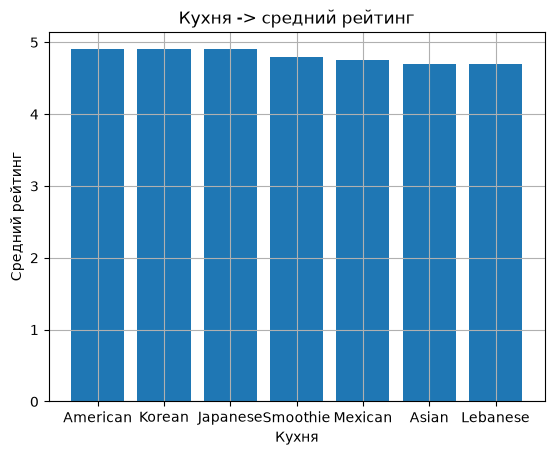

In [13]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

response = requests.get('http://dummyjson.com/recipes')
response.raise_for_status()
recipe = response.json()

df = pd.DataFrame(recipe['recipes'])

df['Total_time'] = df['prepTimeMinutes'] + df['cookTimeMinutes']
df = df[['name', 'cuisine', 'rating', 'Total_time']]
df = df.groupby('cuisine').agg({'rating': 'mean','name': 'count', 'Total_time': 'mean'}).reset_index()#.query('rating >= 5')#.sort_values('rating[1]', ascending=False).head(7).to_csv('cuisine_stats.csv')

df_csv = df[df['name'] >= 5].sort_values('rating', ascending=False)[['cuisine','rating','Total_time']]

print(df_csv)

df_csv.to_csv(r'C:\\NextCloud\\py\\test_py\\hw\\hw15\\cuisine_stats.csv',index=False)

plt.bar(df.sort_values(by=('rating'), ascending=False).head(7)['cuisine'], df.sort_values(by=('rating'), ascending=False).head(7)['rating'])
plt.title('Кухня -> средний рейтинг')
plt.xlabel('Кухня')
plt.ylabel('Средний рейтинг')
plt.grid(True)
plt.show()